# Test de Frequency ICA sur des signaux sinusoïdaux avec TDOA

Ce notebook construit deux sources **multi-sinusoïdales** dont les fréquences dominantes sont différentes, applique des retards distincts sur quatre microphones, puis compare les TDOA estimés aux valeurs connues.

> Une sinusoïde pure ne fournit qu'un seul point de phase. Elle ne permet donc pas, à elle seule, d'estimer la pente $-2\pi fT$. Les sources ci-dessous possèdent plusieurs composantes sinusoïdales communes, avec des pondérations différentes, afin que l'ICA reste identifiable sur plusieurs fréquences.

In [1]:
from itertools import permutations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Permet d'exécuter le notebook depuis la racine ou depuis BSS/Workproof.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / 'BSS').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from BSS.Algo_Separation.Frequency_ica_separation import FrequencyDomainICA
from BSS.Utils.associated_dataclasses import StftParameters
from BSS.Utils.signal_class import MultiSignal, Signal

## 1. Génération des deux sources

La première source est dominée par les basses fréquences, la seconde par les hautes fréquences. Leurs enveloppes temporelles diffèrent pour renforcer leur indépendance statistique.

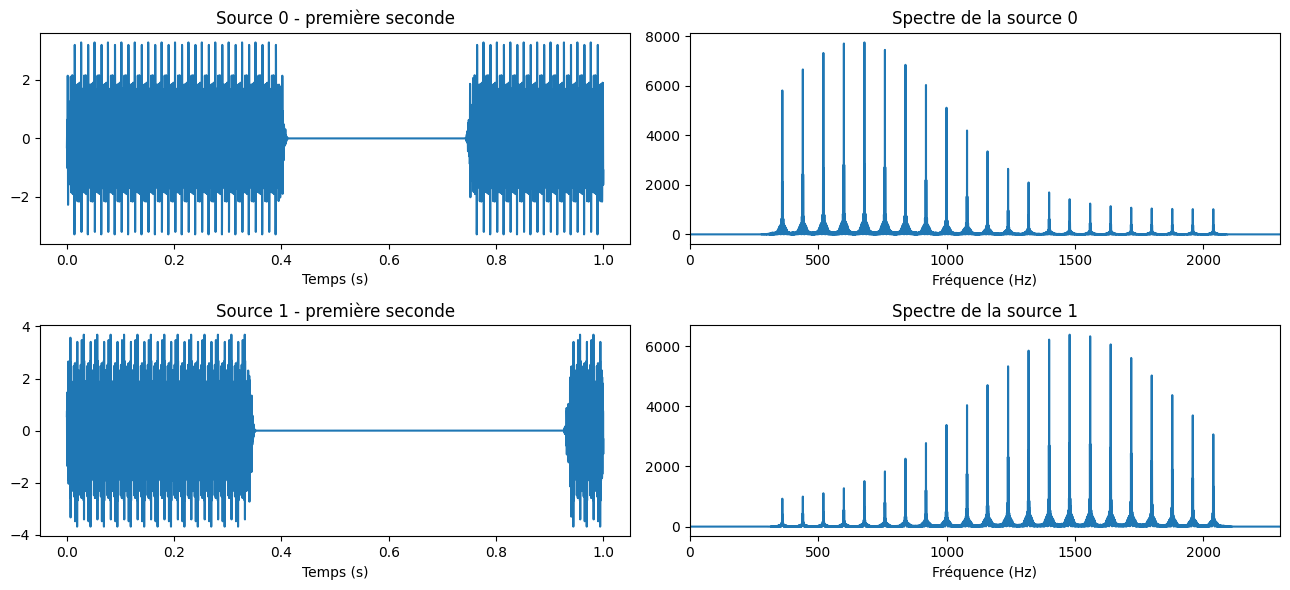

In [2]:
fs = 8_000
duration = 5.0
time = np.arange(int(fs * duration)) / fs
rng = np.random.default_rng(7)

# Enveloppes lissées et différentes pour les deux sources.
raw_envelope_0 = (np.sin(2 * np.pi * 1.3 * time) > -0.15).astype(float)
raw_envelope_1 = (np.sin(2 * np.pi * 0.9 * time + 1.1) > 0.10).astype(float)
smoothing_window = np.hanning(161)
smoothing_window /= smoothing_window.sum()
envelope_0 = np.convolve(raw_envelope_0, smoothing_window, mode='same')
envelope_1 = np.convolve(raw_envelope_1, smoothing_window, mode='same')

# Grille commune de sinusoïdes : les amplitudes donnent deux couleurs
# spectrales différentes tout en conservant de l'information partagée.
sinusoidal_frequencies = np.arange(360, 2_041, 80)
amplitudes_0 = 0.15 + np.exp(-0.5 * ((sinusoidal_frequencies - 650) / 350) ** 2)
amplitudes_1 = 0.15 + np.exp(-0.5 * ((sinusoidal_frequencies - 1_500) / 400) ** 2)
phases_0 = rng.uniform(0, 2 * np.pi, len(sinusoidal_frequencies))
phases_1 = rng.uniform(0, 2 * np.pi, len(sinusoidal_frequencies))

source_0_data = envelope_0 * sum(
    amplitude * np.sin(2 * np.pi * frequency * time + phase)
    for amplitude, frequency, phase in zip(amplitudes_0, sinusoidal_frequencies, phases_0)
)
source_1_data = envelope_1 * sum(
    amplitude * np.sin(2 * np.pi * frequency * time + phase)
    for amplitude, frequency, phase in zip(amplitudes_1, sinusoidal_frequencies, phases_1)
)
source_0_data /= np.std(source_0_data)
source_1_data /= np.std(source_1_data)

source_0 = Signal(source_0_data, fs)
source_1 = Signal(source_1_data, fs)
original_sources = MultiSignal([source_0, source_1])

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for source_index, source in enumerate(original_sources.signals):
    axes[source_index, 0].plot(source.time[:fs], source.data[:fs])
    axes[source_index, 0].set_title(f'Source {source_index} - première seconde')
    frequencies = np.fft.rfftfreq(len(source.data), 1 / fs)
    spectrum = np.abs(np.fft.rfft(source.data))
    axes[source_index, 1].plot(frequencies, spectrum)
    axes[source_index, 1].set_xlim(0, 2_300)
    axes[source_index, 1].set_title(f'Spectre de la source {source_index}')
for axis in axes[:, 0]:
    axis.set_xlabel('Temps (s)')
for axis in axes[:, 1]:
    axis.set_xlabel('Fréquence (Hz)')
plt.tight_layout()

## 2. Création du mélange bruité avec quatre microphones

Les lignes correspondent aux sources et les colonnes aux microphones. Le microphone 0 est la référence : son TDOA vaut zéro pour les deux sources.

SNR gaussien mesuré : 20.00 dB
TDOA théoriques en échantillons :
[[0 2 5 7]
 [0 6 3 9]]


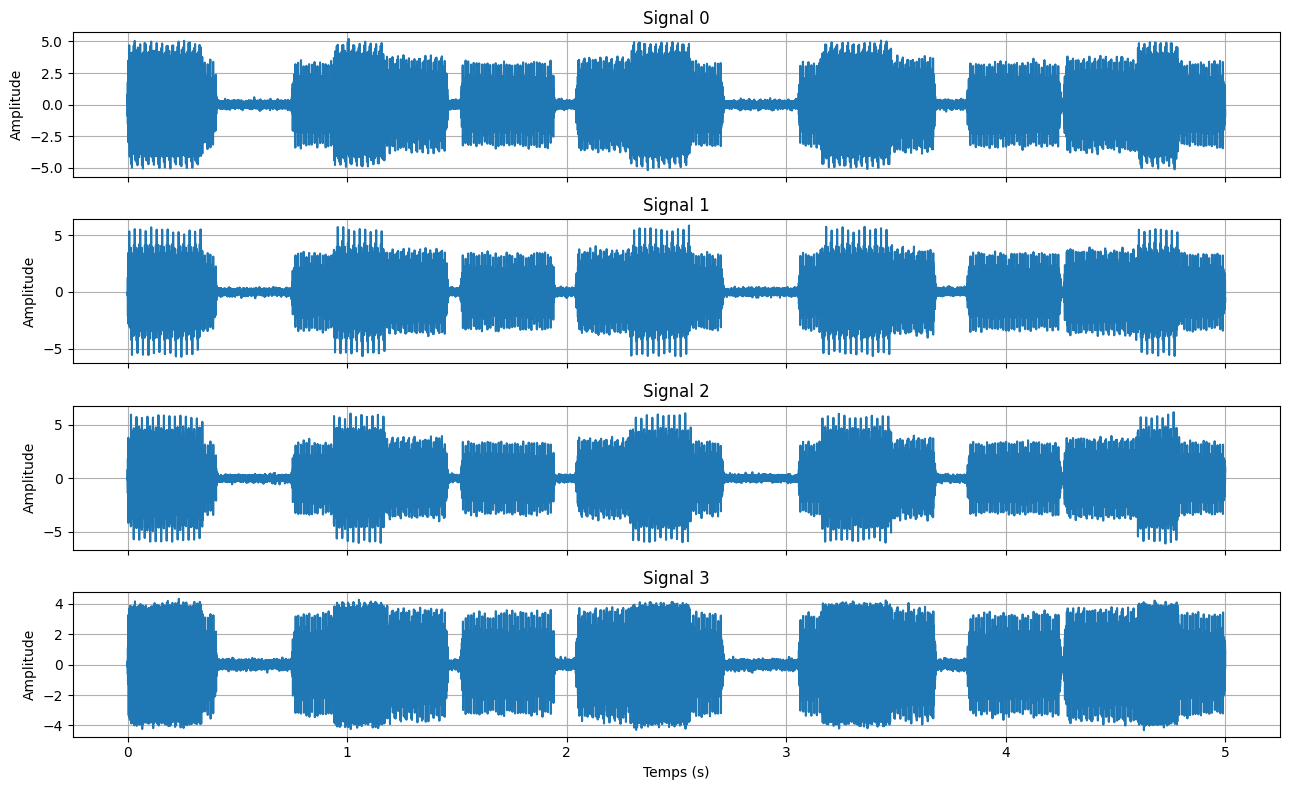

In [3]:
expected_tdoas_samples = np.array([
    [0, 2, 5, 7],  # Source 0
    [0, 6, 3, 9],  # Source 1
])
expected_tdoas_seconds = expected_tdoas_samples / fs

def causal_delay(data, delay_samples):
    delayed = np.zeros_like(data)
    if delay_samples == 0:
        delayed[:] = data
    else:
        delayed[delay_samples:] = data[:-delay_samples]
    return delayed

microphones = np.zeros((4, len(time)))
for microphone_index in range(4):
    microphones[microphone_index] = (
        causal_delay(source_0.data, expected_tdoas_samples[0, microphone_index])
        + causal_delay(source_1.data, expected_tdoas_samples[1, microphone_index])
    )

# Ajout d'un bruit blanc gaussien à un SNR contrôlé.
target_snr_db = 20.0  # Modifier cette valeur pour tester d'autres niveaux de bruit.
clean_microphones = microphones.copy()
gaussian_noise = rng.standard_normal(microphones.shape)
signal_power = np.mean(clean_microphones ** 2)
noise_power_target = signal_power / (10 ** (target_snr_db / 10))
gaussian_noise *= np.sqrt(noise_power_target / np.mean(gaussian_noise ** 2))
microphones = clean_microphones + gaussian_noise
measured_snr_db = 10 * np.log10(
    np.mean(clean_microphones ** 2) / np.mean(gaussian_noise ** 2)
)
mixture = MultiSignal.from_array(microphones, fs)

print(f'SNR gaussien mesuré : {measured_snr_db:.2f} dB')
print('TDOA théoriques en échantillons :')
print(expected_tdoas_samples)
mixture.plot(overlay=False, figsize=(13, 7));

## 3. Séparation Frequency ICA et estimation des TDOA

In [4]:
model = FrequencyDomainICA(
    n_sources=2,
    stft_parameters=StftParameters(
        window='hann',
        nperseg=256,
        noverlap=192,
        nfft=512,
    ),
    n_iter=100,
    max_tdoa_seconds=0.002,
    reference_microphone=0,
    random_state=3,
)

result = model.process_signal(mixture)
estimated_sources = result.sources
estimated_tdoas_samples = result.tdoas_samples

print('TDOA bruts estimés en échantillons :')
print(np.round(estimated_tdoas_samples, 3))

TDOA bruts estimés en échantillons :
[[0.    6.105 3.145 9.096]
 [0.    2.152 4.677 7.225]]


## 4. Alignement de l'ordre des sources et comparaison

L'ordre des sources est intrinsèquement arbitraire en ICA. On teste donc les deux permutations possibles uniquement pour comparer aux sources simulées.

In [5]:
candidate_permutations = list(permutations(range(2)))
best_permutation = min(
    candidate_permutations,
    key=lambda permutation: np.mean(
        (estimated_tdoas_samples[list(permutation)] - expected_tdoas_samples) ** 2
    ),
)
aligned_tdoas_samples = estimated_tdoas_samples[list(best_permutation)]
aligned_sources = [estimated_sources[index] for index in best_permutation]
tdoa_errors_samples = aligned_tdoas_samples - expected_tdoas_samples

print('Permutation retenue :', best_permutation)
print('TDOA théoriques [samples] :\n', expected_tdoas_samples)
print('TDOA estimés     [samples] :\n', np.round(aligned_tdoas_samples, 3))
print('Erreurs            [samples] :\n', np.round(tdoa_errors_samples, 3))
print('RMSE TDOA [samples] :', round(float(np.sqrt(np.mean(tdoa_errors_samples ** 2))), 4))

# Tolérance inférieure à un échantillon sur ce cas synthétique.
np.testing.assert_allclose(aligned_tdoas_samples, expected_tdoas_samples, atol=0.75)

Permutation retenue : (1, 0)
TDOA théoriques [samples] :
 [[0 2 5 7]
 [0 6 3 9]]
TDOA estimés     [samples] :
 [[0.    2.152 4.677 7.225]
 [0.    6.105 3.145 9.096]]
Erreurs            [samples] :
 [[ 0.     0.152 -0.323  0.225]
 [ 0.     0.105  0.145  0.096]]
RMSE TDOA [samples] : 0.1656


## 5. Visualisation des sources séparées

Chaque sortie est une image multicanale de la source. On affiche ici le microphone de référence.

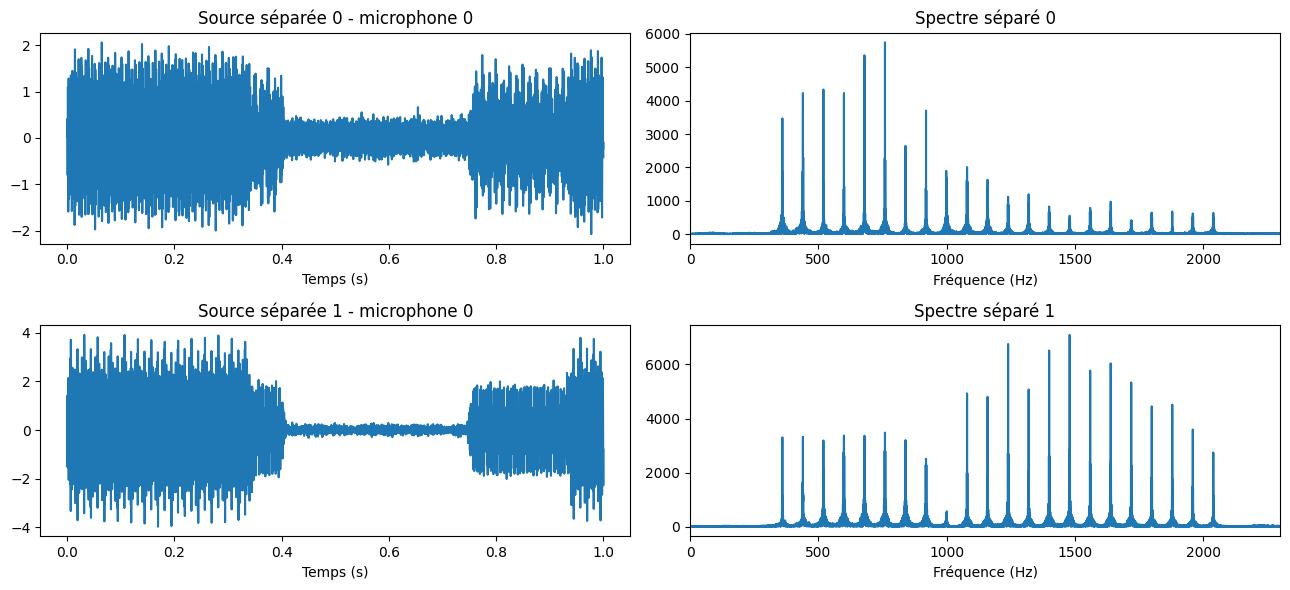

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for source_index, separated_source in enumerate(aligned_sources):
    reference_signal = separated_source.signals[0]
    axes[source_index, 0].plot(reference_signal.time[:fs], reference_signal.data[:fs])
    axes[source_index, 0].set_title(f'Source séparée {source_index} - microphone 0')
    frequencies = np.fft.rfftfreq(len(reference_signal.data), 1 / fs)
    spectrum = np.abs(np.fft.rfft(reference_signal.data))
    axes[source_index, 1].plot(frequencies, spectrum)
    axes[source_index, 1].set_xlim(0, 2_300)
    axes[source_index, 1].set_title(f'Spectre séparé {source_index}')
for axis in axes[:, 0]:
    axis.set_xlabel('Temps (s)')
for axis in axes[:, 1]:
    axis.set_xlabel('Fréquence (Hz)')
plt.tight_layout()